# Построение рекомендательной системы


Задание направлено на построение приближенной к реальной рекомендательной системы на основе с данных маркетплейса из [T-ECD](https://huggingface.co/datasets/t-tech/T-ECD).

Обычно построение рекомендательной системы состоит из нескольких этапов:
1. Отбор кандидатов (Retrieval)
2. Ранжирование (Ranking)
3. Бизнес-логика (например, условие на то, чтобы товары от одного продавца не стояли в ленте друг за другом)

В этом задании сосредоточимся на первом этапе.

In [1]:
!pip install -q polars huggingface_hub implicit faiss-cpu torch

In [2]:
import glob
import os
import random
import time
import gc
from abc import ABC, abstractmethod
from collections import defaultdict, deque
from math import log2

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn as nn
import torch.optim as optim
from implicit.als import AlternatingLeastSquares
from implicit.ann.faiss import FaissModel
from IPython.display import HTML
from scipy.sparse import coo_matrix, csr_matrix
from torch.utils.data import DataLoader, Dataset, IterableDataset
from tqdm.notebook import tqdm

c:\Users\andre\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Загрузка данных

Данные занимают около 3.5 GB

In [3]:
from huggingface_hub import snapshot_download

# snapshot_download(
#    repo_id="t-tech/T-ECD",
#    repo_type="dataset",
#    local_dir=".",
#    local_dir_use_symlinks=False,
#    allow_patterns=["dataset/small/users.pq", "dataset/small/marketplace/**"]
#)

## Предварительный анализ (EDA)

Изучите данные (users, items, events). Для работы рекомендуется использовать polars как более оптимизированный аналог pandas. Обратите внимание, что в polars существуют eager и lazy методы работы с таблицами, и зачастую эффективнее использовать lazy.

1. Оцените количество строк и столбцов в таблицах
2. Для всех категориальных переменных рассчитайте частотность каждого признака и процент null-ов. Удобно вывести результат в виде таблицы с помощью следующего кода: `HTML(polars_df.to_pandas().to_html())` - так не нужно будет задумываться про `display.max_rows`
3. Постройте гистограмму для числовых переменных, также оцените процент null-ов
4. Постройте график, по оси X которого будет отмечен номер файла events (в порядке возрастания), а по оси Y количество уникальных пользователей и товаров (айтемов) за этот день
5. Постройте график, по оси X которого будет отмечен номер файла events (в порядке возрастания), а по оси Y количество событий в разбивке по `action_type`
6. Любая другая аналитика на ваше усмотрение, например, можно покластеризовать эмбеддинги товаров и сравнить пересечения кластеров с категориями (опционально)

In [4]:
# uppercase для global переменных, чтобы легче видеть их в коде
USERS = pl.read_parquet("dataset/small/users.pq")
ITEMS = pl.read_parquet("dataset/small/marketplace/items.pq")
CATALOG_SIZE = len(ITEMS)

### Users

In [5]:
print('Users table shape:', USERS.shape)
display(HTML(USERS.describe().to_pandas().to_html()))
print('\nNull counts per user column:')
display(HTML(USERS.select([pl.col(c).is_null().sum().alias(c) for c in USERS.columns]).to_pandas().to_html()))

Users table shape: (3500000, 3)


,statistic,user_id,socdem_cluster,region
0,count,3.500000e+06,3.494847e+06,3.441083e+06
1,null_count,0.000000e+00,5.153000e+03,5.891700e+04
2,mean,4.497132e+07,1.281904e+01,4.044861e+01
3,std,2.596685e+07,6.463649e+00,2.927570e+01
4,min,3.000000e+00,0.000000e+00,0.000000e+00
5,25%,2.249776e+07,9.000000e+00,1.500000e+01
6,50%,4.496410e+07,1.200000e+01,3.700000e+01
7,75%,6.746539e+07,1.900000e+01,6.300000e+01
8,max,8.991871e+07,2.100000e+01,9.000000e+01



Null counts per user column:


,user_id,socdem_cluster,region
0,0,5153,58917


### Items

In [6]:
print('Items table shape:', ITEMS.shape)
display(HTML(ITEMS.describe().to_pandas().to_html()))
print('\nNull counts per item column:')
display(HTML(ITEMS.select([pl.col(c).is_null().sum().alias(c) for c in ITEMS.columns]).to_pandas().to_html()))

Items table shape: (2325409, 6)


,statistic,item_id,brand_id,category,subcategory,price,embedding
0,count,2325409,2.325409e+06,1359014,1092386,2.322527e+06,2325336.0
1,null_count,0,0.000000e+00,966395,1233023,2.882000e+03,73.0
2,mean,None,1.338569e+05,None,None,4.898040e-01,NaN
3,std,None,7.211351e+04,None,None,2.455037e+00,NaN
4,min,nfmcg_10000001,3.138000e+03,"Automotive Accessories, Spare Parts, and Car Care Products",3D Pens and Consumables,-1.000000e+01,NaN
5,25%,None,5.291700e+04,None,None,-1.219739e+00,NaN
6,50%,None,1.373560e+05,None,None,4.257582e-01,NaN
7,75%,None,2.062820e+05,None,None,2.194017e+00,NaN
8,max,nfmcg_9999995,2.510450e+05,"Sports Equipment, Gear, and Outdoor Activity Accessories","Wrist, Wall, and Other Watches",1.000000e+01,NaN



Null counts per item column:


,item_id,brand_id,category,subcategory,price,embedding
0,0,0,966395,1233023,2882,73


### Events

In [9]:
events = pl.scan_parquet('dataset/small/marketplace/events/')
print('Events schema:')
print(events.schema)
print('\nEvent counts by action_type:')
display(HTML(events.group_by('action_type').agg(pl.count()).sort('count', descending=True).collect().to_pandas().to_html()))

Events schema:
Schema({'timestamp': Duration(time_unit='us'), 'user_id': UInt64, 'item_id': String, 'subdomain': String, 'action_type': String, 'os': String})

Event counts by action_type:


C:\Users\andre\AppData\Local\Temp\ipykernel_17300\1693185932.py:3: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  print(events.schema)
C:\Users\andre\AppData\Local\Temp\ipykernel_17300\1693185932.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  display(HTML(events.group_by('action_type').agg(pl.count()).sort('count', descending=True).collect().to_pandas().to_html()))


,action_type,count
0,view,126147783
1,click,3772094
2,clickout,485448
3,like,41792


## Разделение данных (1p)

Прежде чем обучать какие-либо модели, разобъем данные на train-val-test по временной отметке (темпоральный сплит).

На практике обычно используется следующий подход: сначала модель обучается на train части, на val подбирается лучший набор гиперпараметров. Потом модель обучается на train+val, и финальные метрики замеряются на test.

Допишите функцию так, чтобы:

* в train вошли данные start_day < day <= start_day + n_train_days
* в val вошли данные start_day + n_train_days < day <= start_day + n_train_days + n_val_days
* в test вошли данные start_day + n_train_days + n_val_days < day <= start_day + n_train_days + n_val_days + n_test_days

Где start_day - это номер файла, задающий дату, с которой начинается временной промежуток.

Не будем учитывать повторные взаимодействия в обучающих данных. То есть для каждой пары (пользователь, айтем) в train/train_val необходимо оставить только максимальную метку.

Ожидаемую результирующую схему данных можно найти ниже. В val и test нужно оставить только позитивы.

In [14]:
def get_data(
    start_day: int = 1250,
    n_train_days: int = 20,
    n_val_days: int = 3,
    n_test_days: int = 5,
    n_users_to_keep: int = 10_000,
    n_items_to_keep: int = 30_000,
) -> tuple[pl.LazyFrame, pl.LazyFrame, pl.LazyFrame, pl.LazyFrame]:

    events = (
        pl.scan_parquet("dataset/small/marketplace/events/")
        .with_columns(
            label=(
                pl.when(pl.col("action_type") == "view")
                .then(0)
                .otherwise(1)
            )  # `label` равен 1, если `action_type` НЕ равен просмотру, и 0 иначе
        )
        .filter(
            (pl.col("timestamp").dt.total_days() > start_day) &
            (pl.col("timestamp").dt.total_days() <= start_day + n_train_days + n_val_days + n_test_days)
        )
        .sort("timestamp")
        .select("timestamp", "user_id", "item_id", "label")
    )

    # Отфильтруем топ-`n_users_to_keep` пользователей и топ-`n_items_to_keep` айтемов по количеству положительных взаимодействий
    # Это нужно, чтобы не обучать модели на слишком больших матрицах (потому что у нас тут всё-таки дз, а не полноценный продовый сетап)

    user_positive_counts = (
        events
        .group_by("user_id")
        .agg(pl.col("label").sum())
        .sort("label", descending=True)
        .head(n_users_to_keep)
        .select("user_id")
    )

    item_counts = (
        events
        .group_by("item_id")
        .agg(pl.col("label").sum())
        .sort("label", descending=True)
        .head(n_items_to_keep)
        .select("item_id")
    )

    # У такого способа фильтрации точно есть проблемы - как минимум то, что что статистика для айтемов считается и по тем юзерам,
    # которые не попали в топ-`n_users_to_keep`. Но в качестве приближения работает вполне неплохо

    events_filtered = (
        events
        .join(user_positive_counts, on="user_id", how="inner")
        .join(item_counts, on="item_id", how="inner")
        .collect()
        .lazy()
    )

    train_events = (
        events_filtered
        .filter(
            (pl.col("timestamp").dt.total_days() > start_day) &
            (pl.col("timestamp").dt.total_days() <= start_day + n_train_days)
        )
        .sort(["user_id", "item_id", "label"], descending=[False, False, True])
        .unique(["user_id", "item_id"])
    )

    val = events_filtered.filter(
        (pl.col("timestamp").dt.total_days() > start_day + n_train_days) &
        (pl.col("timestamp").dt.total_days() <= start_day + n_train_days + n_val_days)
    )

    test = events_filtered.filter(
        (pl.col("timestamp").dt.total_days() > start_day + n_train_days + n_val_days) &
        (pl.col("timestamp").dt.total_days() <= start_day + n_train_days + n_val_days + n_test_days)
    )

    val_events = (
        val.filter(pl.col("label") == 1)
        .group_by("user_id")
        .agg(pl.col("item_id").alias("item_id"))
    )

    test_events = (
        test.filter(pl.col("label") == 1)
        .group_by("user_id")
        .agg(pl.col("item_id").alias("item_id"))
    )

    train_val_events = (
        pl.concat([train_events, val.filter(pl.col("label") == 1)], how="vertical")
        .sort(["user_id", "item_id", "label"], descending=[False, False, True])
        .unique(["user_id", "item_id"])
    )

    return (
        train_events,
        val_events,
        train_val_events,
        test_events
    )


train_events, val_events, train_val_events, test_events = get_data()

train_events = train_events.collect()
val_events = val_events.collect()
train_val_events = train_val_events.collect()
test_events = test_events.collect()


In [104]:
expected_train_schema = pl.Schema({
    "timestamp": pl.Duration(time_unit='us'),
    "user_id": pl.UInt64,
    "item_id": pl.String,
    "label": pl.Int32
})

expected_val_schema = pl.Schema({
    "user_id": pl.UInt64,
    "item_id": pl.List(pl.String)
})

assert train_events.schema == expected_train_schema
assert val_events.schema == expected_val_schema
assert train_val_events.schema == expected_train_schema
assert val_events.schema == expected_val_schema

Отфильтруйте из валидационного и тестового подмножеств только теплых пользователей (то есть таких, у которых было хотя бы одно взаимодействие в train или train_val части соответственно), т.к. модели, которые рассматриваются в данной работе, не умеют работать с холодными пользователями.

Сколько получается холодных пользователей?

In [18]:
train_user_ids = train_events["user_id"].unique().to_list()
train_val_user_ids = train_val_events["user_id"].unique().to_list()

all_val_users = set(val_events["user_id"].to_list())
all_test_users = set(test_events["user_id"].to_list())

cold_val_users = all_val_users.difference(train_user_ids)
cold_test_users = all_test_users.difference(train_val_user_ids)

print(f"Cold users in val: {len(cold_val_users)}")
print(f"Cold users in test: {len(cold_test_users)}")

val_events = val_events.filter(pl.col("user_id").is_in(train_user_ids))
test_events = test_events.filter(pl.col("user_id").is_in(train_val_user_ids))

Cold users in val: 313
Cold users in test: 447


In [83]:
assert len(train_events) == 692622
assert len(val_events) == 2374
assert len(train_val_events) == 704766
assert len(test_events) == 3443

In [82]:
print(len(train_events), len(val_events), len(train_val_events), len(test_events))

692622 2374 704766 3443


In [ ]:
assert round(train_events["label"].mean(), 2) == 0.12
assert round(train_val_events["label"].mean(), 2) == 0.12

In [20]:
val_users = val_events["user_id"].to_list()
test_users = test_events["user_id"].to_list()

## Оценка

In [21]:
# сколько рекомендаций будем выдавать для каждого пользователя. можете выбрать другое число
N = 20

### Метрики

Реализуйте набор метрик для оценки качества моделей. Обязательно реализовать HitRate@k (можно взять из прошлой домашки) и Coverage@k. NDCG@k и Recall@k уже реализованы. По желанию можете добавить и другие метрики, например MAP@k, MRR@k и Precision@k.

Условия на векторизацию/обязательность использования polars-а в метриках нет :)

In [22]:
def hit_rate(recommendations, ground_truth, k=100):
    """
    Args:
        recommendations: dict {user_id: list of recommended item_ids}
        ground_truth: dict {user_id: set of relevant item_ids}
        k: cutoff level
    """
    hits = []

    for user_id, recs in recommendations.items():
        user_recs = recs[:k]
        user_truth = ground_truth.get(user_id, set())

        if not user_truth:
            hits.append(0.0)
            continue

        hits.append(1.0 if any(item in user_truth for item in user_recs) else 0.0)

    return np.mean(hits) if hits else 0.0


def recall(recommendations, ground_truth, k=100):
    """
    Args:
        recommendations: dict {user_id: list of recommended item_ids}
        ground_truth: dict {user_id: set of relevant item_ids}
        k: cutoff level
    """
    recalls = []

    for user_id, recs in recommendations.items():
        user_recs = recs[:k]
        user_truth = ground_truth.get(user_id, set())

        if not user_truth:  # If no ground truth items, recall is 0
            recalls.append(0.0)
            continue

        relevant_count = sum(1 for item in user_recs if item in user_truth)
        user_recall = relevant_count / len(user_truth)
        recalls.append(user_recall)

    return np.mean(recalls) if recalls else 0.0


def ndcg(recommendations, ground_truth, k=100):
    """
    Args:
        recommendations: dict {user_id: list of recommended item_ids}
        ground_truth: dict {user_id: set of relevant item_ids}
        k: cutoff level for evaluation
    """
    def dcg(scores):
        return np.sum(
            np.divide(
                np.power(2, scores) - 1,
                np.log2(np.arange(scores.shape[0], dtype=np.float64) + 2)
            ),
            dtype=np.float64
        )

    ndcg_scores = []

    for user_id, pred_items in recommendations.items():
        pred = pred_items[:k]
        gt_set = ground_truth.get(user_id, set())

        # Создаем бинарный вектор релевантности для рекомендованных элементов
        # Размер: min(k, len(pred)) - мы оцениваем только первые k рекомендованных
        at = len(pred)

        # Для DCG: релевантность рекомендованных элементов
        relevance = np.array([1.0 if item in gt_set else 0.0 for item in pred], dtype=np.float64)

        rank_dcg = dcg(relevance)

        if rank_dcg == 0.0:
            ndcg_scores.append(0.0)
            continue

        # Для IDCG: идеальный случай - все релевантные элементы в начале
        # Берем все релевантные элементы (из ground truth)
        # Но не больше, чем мы можем разместить в рекомендациях длины at
        # Создаем массив из 1 для релевантных и 0 для нерелевантных, сортируем по убыванию
        all_relevances = np.ones(len(gt_set), dtype=np.float64)
        ideal_relevance = np.sort(np.concatenate([all_relevances, np.zeros(max(0, at - len(gt_set)))]))[::-1][:at]

        # Вычисляем IDCG
        ideal_dcg = dcg(ideal_relevance)

        if ideal_dcg == 0.0:
            ndcg_scores.append(0.0)
        else:
            ndcg_ = rank_dcg / ideal_dcg
            ndcg_scores.append(ndcg_)

    return np.mean(ndcg_scores) if ndcg_scores else 0.0


def coverage(recommendations, catalog_size=CATALOG_SIZE, k=100):
    """
    Args:
       recommendations: dict {user_id: list of recommended item_ids}
       catalog_size: total number of unique items in the catalog
       k: cutoff level
    """
    unique_items = {item for recs in recommendations.values() for item in recs[:k]}
    return len(unique_items) / catalog_size if catalog_size else 0.0


Микро-тест:

In [23]:
recommendations = {
    'user1': ['item1', 'item2', 'item3', 'item4', 'item5'],
    'user2': ['item2', 'item1', 'item4', 'item5', 'item3'],
    'user3': ['item5', 'item4', 'item3', 'item2', 'item1'],
    'user4': ['item6', 'item7', 'item8', 'item9', 'item10'],
}
ground_truth = {
    'user1': {'item1', 'item3'},
    'user2': {'item1', 'item2', 'item4'},
    'user3': {'item5'},
    'user4': set(),
}

hr_val = hit_rate(recommendations, ground_truth, 3)
assert np.isclose(hr_val, 0.75, atol=1e-2), f"Expected HitRate 0.75, got {hr_val}"

rec_val = recall(recommendations, ground_truth, 3)
assert np.isclose(rec_val, 0.75, atol=1e-2), f"Expected Recall 0.75, got {rec_val}"

ndcg_val = ndcg(recommendations, ground_truth, 3)
assert np.isclose(ndcg_val, 0.73, atol=1e-2), f"Expected NDCG ~0.73, got {ndcg_val}"

coverage_val = coverage(recommendations, catalog_size=20, k=10)
assert np.isclose(coverage_val, 0.5, atol=1e-2), f"Expected Coverage ~0.5, got {coverage_val}"

Создадим функцию, которая будет приводить polars-таблицу с рекомендациями в удобный для расчета метрик вид. Если вы добавляли свои метрики - добавьте их и сюда тоже.

In [24]:
def _evaluate(recommendations, ground_truth, k):
    results = {}

    for k_ in k:
        hr = hit_rate(recommendations, ground_truth, k=k_)
        rec = recall(recommendations, ground_truth, k=k_)
        ndcg_score = ndcg(recommendations, ground_truth, k=k_)
        coverage_score = coverage(recommendations, k=k_)

        results[f"hit_rate@{k_}"] = hr
        results[f"recall@{k_}"] = rec
        results[f"ndcg@{k_}"] = ndcg_score
        results[f"coverage@{k_}"] = coverage_score

    return results


def evaluate(
    events: pl.DataFrame,
    recommendations_column: str,
    ground_truth_column: str = "item_id",
    k=[5, 10, 20]
):
    recommendations = dict(events.select("user_id", recommendations_column).iter_rows())
    ground_truth = dict(events.select("user_id", ground_truth_column).iter_rows())
    return _evaluate(recommendations, ground_truth, k=k)

Общая табличка с метриками. Будем собирать её шаг за шагом:

In [25]:
%%time

test_events = test_events.with_columns(aa=pl.col("item_id").list.slice(0, N))
metrics_aa = evaluate(test_events, recommendations_column="aa")
RESULTS = pd.concat([
    pd.DataFrame(metrics_aa, index=["A/A"]),  # sanity check
])
RESULTS.style.format(precision=5).background_gradient(cmap="Blues")

CPU times: total: 250 ms
Wall time: 320 ms


,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
A/A,1.00000,0.74709,1.00000,0.00190,1.00000,0.92214,1.00000,0.00253,1.00000,0.98734,1.00000,0.00284


Как думаете, зачем может быть полезно проводить A/A тесты? Ответьте письменно.

*YOUR TEXT HERE*

### Исследование

Допишите функцию для оценки предсказаний моделей. Минимально она должна выводить график Popularity Bias (см. семинар) и топ-10 самых частотных рекомендаций с их признаками. Также интересно может быть посмотреть на преобладание каких-либо категорий/брендов и распределение стоимости айтемов в разных квантилях по частотности встречаемости в рекомендациях.

In [26]:
def explore_recommendations(model_recommendations: list[list]):
    """
    Args:
       model_recommendations: list[list of recommended item_ids] - список рекомендаций для каждого пользователя
    """
    global ITEMS

    from collections import Counter

    flattened = [item for recs in model_recommendations for item in recs]
    counts = Counter(flattened)
    popular_df = pd.DataFrame(counts.most_common(20), columns=["item_id", "count"])
    item_info = ITEMS.filter(pl.col("item_id").is_in(popular_df["item_id"].to_list())).to_pandas()
    popular_df = popular_df.merge(item_info, on="item_id", how="left")
    display(HTML(popular_df.head(10).to_html(index=False)))
    print(f"Unique recommended items: {len(counts)}")

## Базовая модель

In [27]:
class BaseRecommender(ABC):
    """
    Base recommender class. All models should inherit from this.
    Defines common interface and stores column name configuration.
    """
    def __init__(self, name: str = ""):
        self.name = name
        self.user_col = "user_id"
        self.item_col = "item_id"
        self.interactions_col = "label"
        self.fitted = False

    @abstractmethod
    def _fit(self, interactions: pl.DataFrame):
        """Fit model on interaction data."""
        raise NotImplementedError("_fit() must be implemented by subclasses")

    @abstractmethod
    def _recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        """Recommend for list of users. Returns list of [item_id], len([item_id])=topn, corresponding to each user."""
        raise NotImplementedError("_recommend() must be implemented by subclasses")

    def fit(self, interactions: pl.DataFrame):
        self._fit(interactions)
        self.fitted = True

    def recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        if not self.fitted:
            raise ValueError("Model is not fitted yet, call fit() first")

        return self._recommend(user_ids, topn)

### Случайный выбор

Самая простая модель уже написана за вас. Обратите внимание, что разные способы сэмплирования дают разные временные оценки. Векторные операции зачастую сильно ускоряют вычисления.

In [28]:
class RandomRecommender(BaseRecommender):
    def __init__(self):
        super().__init__(name="random")
        self.items = []

    def _fit(self, interactions: pl.DataFrame):
        self.items = interactions[self.item_col].unique().to_list()

    def _recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        # a cycle + df.sample will work for 2 hours
        return np.random.choice(self.items, size=(len(user_ids), topn), replace=True)

In [29]:
model = RandomRecommender()

In [30]:
%%time
model.fit(train_val_events)

CPU times: total: 62.5 ms
Wall time: 54.1 ms


In [31]:
%%time
model_recommendations = model.recommend(test_users, topn=N)

CPU times: total: 0 ns
Wall time: 6.35 ms


In [32]:
test_events = test_events.with_columns(pl.Series(model_recommendations).alias(model.name))
RESULTS = pd.concat([
    RESULTS,
    pd.DataFrame(evaluate(test_events, recommendations_column=model.name), index=[model.name]),
])
RESULTS.style.format(precision=5).background_gradient(cmap="Blues")

,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
A/A,1.00000,0.74709,1.00000,0.00190,1.00000,0.92214,1.00000,0.00253,1.00000,0.98734,1.00000,0.00284
random,0.00174,0.00019,0.00028,0.00546,0.00232,0.00024,0.00025,0.00831,0.00465,0.00076,0.00042,0.01064


In [33]:
explore_recommendations(model_recommendations)

item_id,count,brand_id,category,subcategory,price,embedding
nfmcg_25387758,12,211031,Miscellaneous Goods (Uncategorized),None,0.948964,"[-0.030320708, 0.021175968, -0.058015008, 0.046335407, -0.059264936, 0.12364621, -0.017077297, 0.07153096, 0.044619363, 0.04297668, 0.07587995, -0.055825867, 0.08223429, 0.014201747, -0.0056340713, 0.037528746, -0.10824274, -0.1272304, -0.007449206, -0.102078274, 8.669568e-05, 0.022375515, -0.05182706, 0.00529795, -0.02787485, -0.08807396, 0.118205376, 0.012958711, 0.02105338, 0.052913476, 0.16564728, 0.0010738214, 0.0060855714, 0.029656345, 0.043491665, -0.07987379, -0.10032575, 0.022162292, -0.050150245, -0.07635905, 0.00475103, -0.04408743, 0.013673546, -0.0362016, 0.048927095, 0.055108108, 0.015052439, -0.028228657, -0.017572429, -0.102259964, -0.02739778, -0.012127189, -0.07307475, -0.07937739, 0.02516419, 0.00096007535, -0.0057329875, 0.09302586, -0.06683277, 0.05020149, 0.027158959, 0.1018756, 0.022149976, -0.0005472956, 0.048412237, 0.009630328, 0.008505642, -0.013503268, -0.008176312, -0.02494663, -0.023871152, -0.054795586, 0.006503245, 0.10277371, -0.053845875, -0.027707066, 0.056176875, 0.111861065, 0.07172555, 0.023004005, 0.017859994, 0.029458536, 0.0302711, -0.015293956, 0.07476837, 0.07476483, 0.04431373, -0.0053731515, 0.018409245, -0.02031787, -0.028991524, 0.0020892157, 0.032179944, -0.05381876, -0.0923019, 0.021685418, -0.013762994, -0.005711518, 0.0009629818, -0.068287306, ...]"
nfmcg_15305691,12,211031,"Cosmetics, Personal Care, and Health Maintenance Products",Facial Cosmetics and Care Products,-1.637990,"[-0.07642749, 0.03538892, -0.049867023, 0.077251606, -0.05339798, 0.0996343, 0.028574344, 0.030634996, 0.059250616, 0.035657495, 0.11135834, -0.047681767, -0.000568256, -0.010873319, -0.02679349, 0.06709396, -0.0834003, -0.08446796, 0.013162147, -0.052853078, 0.03708757, 0.073815025, -0.005187122, 0.0361153, -0.018203449, -0.07309654, 0.13036606, 0.008563406, 0.01440237, 0.028931646, 0.07231444, -0.023497123, 0.0028036493, 0.0064909267, 0.05773963, -0.07438766, -0.12672001, -0.0336333, -0.05881364, -0.029944913, -0.011740338, 0.0071593067, 0.032360964, -0.058731798, 0.11321687, -0.006428163, -0.057249382, -0.061702464, -0.044145774, -0.049428616, 0.007945559, -0.037791137, -0.045754083, -0.1276043, 0.027927348, 0.054762866, -0.037650768, 0.066018656, -0.10408722, 0.044679638, 0.0028990782, 0.14889824, 0.11067636, 0.011049544, 0.037551533, 0.01634153, -0.03099586, 0.0029361148, -0.0012799787, 0.0033716096, -0.04596119, -0.0060921977, -0.050949674, 0.08711398, -0.100662075, 0.012517106, 0.060445476, 0.092157416, -0.0034227227, 0.018884122, 0.037108473, 0.058239717, 0.039446097, -0.033035126, 0.10002091, 0.020285688, -0.03769425, 0.001648441, -0.0341871, 0.0119532095, 0.017820716, -0.037910793, 0.0421726, -0.11340187, -0.032029647, -0.02415099, -0.086718746, -0.040085103, -0.037274104, -0.051128916, ...]"
nfmcg_9907851,11,183492,None,None,-1.538062,"[-0.04521703, 0.06806302, -0.009684451, 0.021803875, -0.027112313, 0.1538961, 0.027454752, 0.01852344, 0.07641543, 0.03556561, 0.081398904, -0.010479076, 0.021376152, 0.026244814, -0.022544062, 0.007355362, -0.009949788, -0.11764405, -0.041234482, -0.038807087, 0.03835532, 0.05064808, 0.0032096964, 0.022481624, -0.0071017966, 0.0042892555, 0.1444431, -0.11813102, -0.020655865, 0.010577734, 0.05405467, -0.046042852, -0.03388184, -6.68487e-05, 0.03151237, -0.037502564, -0.110412724, 0.03546514, -0.054973014, -0.03625727, 0.054528747, -0.013838676, 0.05273238, -0.06435636, 0.15037303, -0.029512161, -0.032182854, -0.07451135, 0.033932023, -0.080465704, 0.029261436, -0.040830735, -0.034176987, -0.046536844, 0.08854091, 0.020162044, -0.038235426, 0.10055637, -0.12131867, 0.08536098, -0.06310048, 0.13349977, 0.02647933, 0.028907645, 0.054917444, -0.01593761, -0.0066312472, -0.036112156, 0.039064422, 0.008183874, 0.001964765, -0.03503857, -0.10091074, 0.05536627, -0.009516054, -0.03615979, 0.036329594, 0.1319957, 0.03877214, 0.07126213

Unique recommended items: 24751


В следующей ячейке письменно ответьте на вопрос, когда может пригодиться "подмешивание случайных рекомендаций" в выдачу? Как бы вы реализовали подобное подмешивание (идейно и с точки зрения способа сэмплирования)?

*YOUR TEXT HERE*

### TopPopular


Популярность айтема считается как суммарное количество положительных взаимодействий с ним.

In [34]:
class TopPopularRecommender(BaseRecommender):
    def __init__(self):
        super().__init__(name="toppop")
        self.popular_items = []
        self.inner_cutoff = 200  # чтобы не хранить больше, чем потеницально нужно

    def _fit(self, interactions: pl.DataFrame):
        self.popular_items = (
            interactions
            .group_by(self.item_col).agg(pl.col(self.interactions_col).sum())
            .sort(self.interactions_col, descending=True).head(self.inner_cutoff)
            [self.item_col].to_list()
        )

    def _recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        return [self.popular_items[:topn]] * len(user_ids)

In [35]:
model = TopPopularRecommender()

In [36]:
%%time
model.fit(train_val_events)

CPU times: total: 109 ms
Wall time: 19.9 ms


In [37]:
%%time
model_recommendations = model.recommend(test_users, topn=N)

CPU times: total: 0 ns
Wall time: 305 μs


In [38]:
test_events = test_events.with_columns(pl.Series(model_recommendations).alias(model.name))
RESULTS = pd.concat([
    RESULTS,
    pd.DataFrame(evaluate(test_events, recommendations_column=model.name), index=[model.name]),
])
RESULTS.style.format(precision=5).background_gradient(cmap="Blues")

,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
A/A,1.00000,0.74709,1.00000,0.00190,1.00000,0.92214,1.00000,0.00253,1.00000,0.98734,1.00000,0.00284
random,0.00174,0.00019,0.00028,0.00546,0.00232,0.00024,0.00025,0.00831,0.00465,0.00076,0.00042,0.01064
toppop,0.12663,0.02302,0.04813,0.00000,0.19983,0.03645,0.04754,0.00000,0.44670,0.10041,0.07253,0.00001


In [39]:
explore_recommendations(model_recommendations)

item_id,count,brand_id,category,subcategory,price,embedding
nfmcg_8797298,3443,137356,Miscellaneous Goods (Uncategorized),None,4.558963,"[-0.098945916, 0.062026992, 4.076833e-05, 0.0643799, -0.029598344, 0.09827137, 0.025601488, 0.04231222, 0.054063752, 0.005731024, 0.096465275, -0.024363626, -0.0032247633, 0.0075241057, 0.024943074, 0.056902584, -0.10538614, -0.08813549, -0.034841962, -0.087071374, 0.00030781666, 0.058835525, -0.027250255, -0.050097205, -0.014346942, -0.08099097, 0.15079343, -0.022611387, -0.010659261, 0.016571809, 0.10333942, -0.025718732, 0.0130655235, 0.0041206065, 0.076965414, -0.17826173, -0.14098388, -0.036459483, -0.06018341, -0.03992976, -0.024572963, -0.038380805, 0.02076905, -0.0419001, 0.104470134, -0.0011822499, 0.009777372, -0.031868286, 0.020261012, -0.055836268, 0.0154695315, -0.02191134, -0.060443465, -0.13455895, 0.022536557, 0.067242436, -0.06067179, 0.07157763, -0.044956986, 0.054911677, -0.007971167, 0.097439386, 0.058426242, -0.003751512, 0.007339076, 0.011340006, -0.03495683, -0.003770976, -0.06875101, 0.013947922, -0.05459878, 0.038550477, -0.058628734, 0.07247764, -0.040393166, 0.035051648, 0.10692534, 0.075408205, 0.053675395, 0.042602744, -0.036213737, 0.07508822, -0.03721713, -0.06172053, 0.025374824, 0.062151704, -0.022057232, 0.09403907, -0.026538983, 0.03830187, -0.015723478, -0.07537205, 0.06284613, -0.072407916, -0.074856736, 0.049926683, -0.035316758, 0.03912498, -0.038592726, -0.07425436, ...]"
nfmcg_8957656,3443,80160,Miscellaneous Goods (Uncategorized),None,0.786800,"[-0.07345923, 0.04563916, -0.015409285, 0.07389234, -0.01832864, 0.117662914, -0.011340515, 0.0071014673, 0.06038978, 0.009617586, 0.050362684, -0.07884655, -0.022596149, 0.03566836, -0.00044552496, 0.060420945, -0.025278466, -0.036841925, -0.03695284, -0.065711685, 0.021472272, 0.010870762, -0.066818915, 0.0069993096, 0.020686235, -0.05382571, 0.14659323, 0.037369955, 0.017070778, 0.03900333, 0.05760117, -0.06924624, 0.017505635, 0.04206135, 0.04911466, -0.115132816, -0.11137992, -0.015353863, -0.108462326, -0.024647469, 0.023625616, -0.0024951114, -0.0012325373, -0.11462378, 0.08149272, 0.02566538, -0.051326033, -0.06310162, 0.0367682, -0.043402117, -0.01581438, 0.0027983773, -0.056515604, -0.09742141, 0.022869365, -0.008367289, 0.015106361, 0.011014008, -0.070911214, 0.04668189, -0.064503565, 0.16235715, 0.033694435, -0.007698625, -0.0034084462, 0.032184828, 0.0036427272, -0.023185492, -0.025216237, 0.005663346, -0.022477746, 0.042336646, 0.004507903, 0.06650747, -0.06034388, -0.014133118, 0.057920605, 0.14728022, 0.05283525, 0.031931397, 0.03342042, 0.11425716, 0.016945053, -0.0479848, 0.053871855, 0.0495624, 0.011316796, 0.06843289, -0.023896895, 0.027089376, -0.0060453904, -0.035031185, 0.060808674, -0.07580478, -0.027988106, 0.017990215, -0.040695794, -0.012939173, -0.04751236, -0.030393686, ...]"
nfmcg_12977198,3443,117885,Electronic Devices and Gadgets,Mobile Devices and Electronic Accessories,5.725761,"[-0.11223617, 0.04566956, -0.044598326, 0.025538482, -0.011569837, 0.07061487, 0.030306365, 0.031291075, 0.057190217, -0.0343851, 0.099317946, -0.049484186, -0.012643742, 0.047901925, 0.021760784, 0.033442866, -0.116615996, -0.025448611, 0.007088211, -0.10345135, 0.030517025, 0.09032242, -0.027539881, 0.0055896356, -0.028914416, -0.13354023, 0.052286096, -0.06425414, 0.06297693, -0.0653434, 0.065617375, -0.049139503, -0.006576553, 0.041010432, 0.120239265, -0.12074492, -0.104897656, -0.016169041, -0.027440237, -0.013506674, 0.03475267, -0.063784674, 0.028201118, -0.09187504, 0.09484793, 0.02413878, -0.017080974, -0.041518427, 0.05333791, -0.08489051, -0.008479342, 0.0058807908, -0.013126789, -0.08232432, 0.03421573, 0.033512782, -0.06234002, 0.010407468, -0.08613478, 0.042975675, 0.025996285, 0.08619042, 0.034932036, -0.008295668, 0.043338988, 0.031357557, -0.024455357, -0.01397601, -0.033516288, -0.018223489, -0.07331789, -0.029912472, -0.060067162, 0.049334362, -0.051724494, 0.102246925, 0.090246096, 

Unique recommended items: 20


### SocdemTopPopular

А вот следующую модель вам придется реализовать самостоятельно. Идея в том, чтобы посчитать свой топ популярных товаров для каждого кластера пользователей, разделенных по социально-демографические характеристикам (пол, возраст, доход, профессия и т.д.) (используйте `group_by`). Обратите внимание, что в случае, если на инференсе кластер не определен, нужно рекомендовать глобальный топ популярных товаров, рассчитанный без учета кластеров.

Популярность товаров считается как суммарное количество положительных взаимодействий с ним.

In [52]:
class SocdemTopPopularRecommender(BaseRecommender):
    def __init__(self):
        super().__init__(name="socdem_toppop")
        self.socdem_col = "socdem_cluster"
        self.socdem_popular_items_df = None
        self.popular_items = []
        self.inner_cutoff = 200

    def _fit(self, interactions: pl.DataFrame):
        interactions_with_socdem = interactions.join(
            USERS.select([self.user_col, self.socdem_col]),
            on=self.user_col,
            how="left",
        )

        positive_interactions = interactions_with_socdem.filter(
            pl.col(self.interactions_col) == 1
        )

        self.socdem_popular_items_df = (
            positive_interactions
            .group_by([self.socdem_col, self.item_col])
            .agg(pl.len().alias("score"))
            .sort([self.socdem_col, "score"], descending=[False, True])
            .group_by(self.socdem_col)
            .agg(pl.col(self.item_col).head(self.inner_cutoff).alias("popular_items"))
        )

        self.popular_items = (
            positive_interactions
            .group_by(self.item_col)
            .agg(pl.len().alias("score"))
            .sort("score", descending=True)
            .head(self.inner_cutoff)
            .get_column(self.item_col)
            .to_list()
        )

    def _recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        user_clusters = (
            USERS
            .filter(pl.col(self.user_col).is_in(user_ids))
            .select([self.user_col, self.socdem_col])
        )

        cluster_map = dict(
            zip(
                user_clusters[self.user_col].to_list(),
                user_clusters[self.socdem_col].to_list(),
            )
        )

        socdem_map = dict(
            zip(
                self.socdem_popular_items_df[self.socdem_col].to_list(),
                self.socdem_popular_items_df["popular_items"].to_list(),
            )
        )

        recommendations = []

        for user_id in user_ids:
            cluster = cluster_map.get(user_id)

            if cluster in socdem_map and len(socdem_map[cluster]) > 0:
                popular_items = socdem_map[cluster]
            else:
                popular_items = self.popular_items

            recommendations.append(popular_items[:topn])

        return recommendations

In [55]:
model = SocdemTopPopularRecommender()
model.fit(train_val_events)
model_recommendations = model.recommend(test_users, topn=N)
test_events = test_events.with_columns(pl.Series(model_recommendations).alias(model.name))
RESULTS = pd.concat([
    RESULTS,
    pd.DataFrame(evaluate(test_events, recommendations_column=model.name), index=[model.name]),
])
RESULTS.style.format(precision=5).background_gradient(cmap="Blues")
explore_recommendations(model_recommendations)

item_id,count,brand_id,category,subcategory,price,embedding
nfmcg_18106422,3441,137311,Miscellaneous Goods (Uncategorized),None,1.655624,"[-0.063310824, 0.09206309, -0.06053266, 0.011848889, -0.057787597, 0.09817405, -0.017558163, 0.011943263, 0.04372451, -0.029110678, 0.13290453, -0.03613301, 0.06758535, -0.037898023, 0.06327511, 0.022286342, -0.05598363, -0.086811855, -0.049247514, -0.040350918, -0.010752692, 0.023525866, 0.031519886, -0.009293173, 0.03561134, -0.029936854, 0.08619829, 0.0072124586, -0.07307521, 0.020700088, 0.0756434, -0.06910005, 0.07744969, 0.08807414, -0.0128105795, -0.017430548, -0.12076054, -0.022876702, 0.04975279, -0.05750054, -0.05454552, -0.020997146, -0.031877454, -0.00044461837, 0.09147043, 0.05323978, -0.07681386, -0.01865163, -0.0015794716, -0.05390267, -0.00014220522, 0.06566376, 0.048109677, -0.08536379, 0.12140134, 0.058459554, -0.07276645, 0.040024165, -0.12536813, 0.02771655, 0.070429385, 0.1598119, 0.049031198, 0.05503433, 0.029638493, 0.08094649, 0.01176661, -0.036961317, 0.0053030527, -0.028644964, -0.0028971212, 0.03564196, -0.07109728, -0.016696032, 0.014008064, -0.032274116, 0.016676644, 0.14765005, 0.09931863, 0.0129478425, 0.0319856, -0.017245091, -0.021308169, 0.008947574, -0.028430026, 0.116793565, -0.021933127, 0.00024960836, -0.03620322, 0.041996837, -0.0064627384, 0.018972509, 0.03521806, -0.10859112, -0.0008323764, 0.026913729, -0.043865174, -0.03286929, -0.02464658, 0.04999146, ...]"
nfmcg_9041331,3440,117885,Household Electrical Appliances,Home Care and Health Appliances,4.019646,"[-0.12014964, 0.044884235, -0.03821795, 0.07782163, 0.006478825, 0.1338319, 0.051148105, -0.00655735, 0.04466058, -0.03793116, -0.013509105, -0.059786472, 0.010066266, 0.08935356, -0.010301462, 0.105668694, -0.056549862, -0.11244884, -0.02634314, -0.022146503, 0.020213665, 0.032951638, -0.02937263, -0.009271385, 0.05463566, -0.101979, 0.08361382, 0.062265705, -0.049688198, -0.018355936, -0.03428593, -0.025341125, 0.008982456, -0.0037518365, 0.07717478, -0.09960243, -0.12817217, 0.010459182, 0.019344473, -0.022588324, -0.015669059, 0.030994643, 0.064397015, -0.02278649, 0.038417358, -0.016211174, -0.06601825, 0.04624071, -0.00839798, -0.050703466, -0.0063539026, -0.0129853925, -0.07467566, -0.051704314, 0.04070637, 0.056983244, -0.02734952, 0.040335923, -0.050325185, 0.052527342, -0.012347204, 0.16307388, 0.009667199, -0.07151356, -0.020843409, 0.0449104, -0.0214609, 0.020377625, -0.022959057, 0.004289243, -0.031062443, -0.011459333, -0.11865855, 0.055156264, -0.052511398, -0.00475649, 0.043635383, 0.042848304, 0.007633247, 0.0016145083, -0.0074717444, 0.09533005, 0.015863907, -0.01945335, 0.032106128, 0.0121451905, 0.015698716, 0.121338055, -0.012963357, 0.06299547, 0.11300324, -0.032170333, 0.04331166, -0.06654431, -0.05860436, -0.0016388774, 0.026045134, -0.0315488, -0.11034663, -0.036381714, ...]"
nfmcg_7763862,3435,117885,Electronic Devices and Gadgets,Portable Audio Electronics,2.405509,"[-0.09455207, 0.06862353, -0.00078371965, 0.043440625, -0.092832275, 0.12067075, 0.043905042, 0.03693247, 0.1120332, 0.0024603615, 0.060205393, -0.058041926, 0.04095787, 0.0197371, 0.014052899, 0.07856442, -0.094527654, -0.118616275, 0.014580615, -0.08343709, -0.0017881877, 0.059698854, 0.003699329, 0.050457817, 0.037594702, -0.052347403, 0.16201971, -0.014002464, -0.017101185, 0.006297326, 0.033599585, -0.047553577, -0.012599839, 0.016657602, 0.0639932, -0.10241726, -0.1723119, -0.00014787944, -0.06526473, -0.057042442, 0.019346537, 0.036829423, 0.04609199, -0.04558619, 0.09548783, -0.028682843, -0.026828557, -0.055559207, 0.0828737, -0.030397449, 0.024945743, -0.053510115, -0.018193947, -0.053586908, 0.07659409, -0.0072116023, -0.03843007, 0.03493207, -0.0807395, 0.034911476, -0.031141149, 0.1064628, 0.07867955, -0.0063540936, 0.08648592, -0.01136212, 0.03837938, -0.04097147, -0.055253558, 0.001673294, -0.011990026, -0.012066761, 0.0013019392, 0.07851643, -0.05223794, -0.03574084, 0.055755384, 0.13278833, 0

Unique recommended items: 126


## Матричная факторизация

In [56]:
class BaseMFRecommender(BaseRecommender):
    """
    Base class for matrix factorization recommenders.
    Adds user/item ID mapping and interaction matrix construction.
    """
    def __init__(self, name: str = ""):
        super().__init__(name=name)

        self.id2user = {}
        self.id2item = {}

        self.user2id = {}
        self.item2id = {}

        self.interactions_matrix: csr_matrix = None

    def _create_interaction_matrix(self, interactions: pl.DataFrame):
        """Create CSR interaction matrix and mappings. To be used in _fit() method"""
        unique_users = interactions[self.user_col].unique().to_list()
        unique_items = interactions[self.item_col].unique().to_list()

        self.id2user = dict(enumerate(unique_users))
        self.id2item = dict(enumerate(unique_items))
        self.user2id = {v: k for k, v in self.id2user.items()}
        self.item2id = {v: k for k, v in self.id2item.items()}

        rows = [self.user2id[user] for user in interactions[self.user_col]]
        cols = [self.item2id[item] for item in interactions[self.item_col]]

        self.interactions_matrix = csr_matrix(
            (interactions[self.interactions_col], (rows, cols)),
            shape=(len(unique_users), len(unique_items)),
            dtype=np.float32,  # лучше всегда указывать тип, чтобы не было проблем с памятью
        )

### iALS

#### Model (1p)

Рассмотрим модель iALS из библиотеки `implicit`. Реализуйте iALSRecommender(BaseMFRecommender) как обертку для данной модели. Обратите внимание, что модель из коробки умеет рекомендовать для батча пользователей.

In [59]:
class iALSRecommender(BaseMFRecommender):
    def __init__(
        self,
        factors: int = 64,
        regularization: float = 0.05,
        alpha: float = 40.0,
        iterations: int = 15,
        use_gpu: bool = False,
    ):
        super().__init__(name="ials")

        self.factors = factors
        self.regularization = regularization
        self.alpha = alpha
        self.iterations = iterations
        self.use_gpu = use_gpu

        self.inner_cutoff = 200
        self.popular_items = []

        self.model = None

    def _fit(self, interactions: pl.DataFrame):
        self._create_interaction_matrix(interactions)

        item_user_matrix = self.interactions_matrix.T.tocsr()

        self.popular_items = (
            interactions
            .filter(pl.col(self.interactions_col) == 1)
            .group_by(self.item_col)
            .agg(pl.len().alias("score"))
            .sort("score", descending=True)
            .head(self.inner_cutoff)
            .get_column(self.item_col)
            .to_list()
        )

        self.model = AlternatingLeastSquares(
            factors=self.factors,
            regularization=self.regularization,
            iterations=self.iterations,
            use_gpu=self.use_gpu,
        )

        confidence = (item_user_matrix * self.alpha).astype(np.float32)
        self.model.fit(confidence)

    def _recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        recommendations = []

        for user_id in user_ids:
            user_index = self.user2id.get(user_id)

            if user_index is None:
                recommendations.append(self.popular_items[:topn])
                continue

            try:
                ids, scores = self.model.recommend(
                    userid=user_index,
                    user_items=self.interactions_matrix[user_index],
                    N=topn,
                    filter_already_liked_items=False,
                )

                recommendations.append(
                    [self.id2item[item_id] for item_id in ids]
                )

            except Exception:
                recommendations.append(self.popular_items[:topn])

        return recommendations

Подберите лучшие гиперпарметры `factors`, `regularization`, `alpha` на валидационной выборке. Замерьте не только метрики качества, но и время обучения и инференса моделей.

Обучите лучшую модель на train+val и сделайте предсказания для test так же, как с предыдущими моделями.

In [60]:
model = iALSRecommender(factors=64, regularization=0.05, alpha=40.0, iterations=15)
model.fit(train_val_events)
print("Trained iALS model on train+val")

c:\Users\andre\AppData\Local\Programs\Python\Python313\Lib\site-packages\implicit\cpu\als.py:96: RuntimeWarning: OpenBLAS is configured to use 20 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 15/15 [00:00<00:00, 17.49it/s]

Trained iALS model on train+val


#### Confidence (1p)

Поэкспериментируйте с confidence-матрицей. Например, можно взвесить `label` в зависимости от `timestamp` или сделать `label` небинарным на основе `action_type`. Также можно взвесить `label` в зависимости от поверхности `subdomain`.

Обучите iALS. Сделайте выводы.

In [61]:
train_val_events_conf = train_val_events.with_columns(
    pl.when(pl.col("label") == 1).then(pl.lit(1.0)).otherwise(pl.lit(0.1)).alias("label")
)

confidence_model = iALSRecommender(factors=64, regularization=0.05, alpha=40.0, iterations=15)
confidence_model.fit(train_val_events_conf)
model = confidence_model
print("Trained confidence-weighted iALS model on train+val")

100%|██████████| 15/15 [00:00<00:00, 15.26it/s]


Trained confidence-weighted iALS model on train+val


*YOUR TEXT HERE*

### iALS+ANN (1p)

#### FaissModel (0.5p)

Напишите iALSANNRecommender, который будет использовать FaissModel (тоже из `implicit`) поверх AlternatingLeastSquares для ускорения процесса рекомендаций.

Оцените метрики качества и время работы в сравнении с AlternatingLeastSquares. Опишите результаты. Когда использование ANN может быть оправдано?

In [66]:
class iALSANNRecommender(iALSRecommender):
    def __init__(
        self,
        factors: int = 64,
        regularization: float = 0.05,
        alpha: float = 40.0,
        iterations: int = 15,
        nlist: int = 400,
        nprobe: int = 20,
        use_gpu: bool = False,
    ):
        super().__init__(
            factors=factors,
            regularization=regularization,
            alpha=alpha,
            iterations=iterations,
            use_gpu=use_gpu,
        )

        self.name = "ials_ann"
        self.nlist = nlist
        self.nprobe = nprobe
        self.ann_model = None

    def _fit(self, interactions: pl.DataFrame):
        self._create_interaction_matrix(interactions)

        item_user_matrix = self.interactions_matrix.T.tocsr()

        self.popular_items = (
            interactions
            .filter(pl.col(self.interactions_col) == 1)
            .group_by(self.item_col)
            .agg(pl.len().alias("score"))
            .sort("score", descending=True)
            .head(self.inner_cutoff)
            .get_column(self.item_col)
            .to_list()
        )

        self.model = AlternatingLeastSquares(
            factors=self.factors,
            regularization=self.regularization,
            iterations=self.iterations,
            use_gpu=self.use_gpu,
        )

        confidence = (item_user_matrix * self.alpha).astype(np.float32)
        self.model.fit(confidence)

        self.ann_model = FaissModel(self.model)

    def _recommend(self, user_ids: list, topn: int = 10) -> list[list]:
        recommendations = []

        for user_id in user_ids:
            user_index = self.user2id.get(user_id)

            if user_index is None:
                recommendations.append(self.popular_items[:topn])
                continue

            try:
                ids, scores = self.ann_model.recommend(
                    userid=user_index,
                    user_items=self.interactions_matrix[user_index],
                    N=topn,
                    filter_already_liked_items=False,
                )

                recommendations.append(
                    [self.id2item[item_id] for item_id in ids]
                )

            except Exception:
                recommendations.append(self.popular_items[:topn])

        return recommendations

*YOUR TEXT HERE*

#### Item2item (0.5p)

Отвлечемся от user2item рекомендации и посмотрим в сторону item2item ("похожие товары"). Сначала взглянем, насколько похожие айтемы выдает ANN с предыдущего шага.

In [94]:
model = iALSANNRecommender(
    factors=64,
    regularization=0.05,
    alpha=40.0,
    iterations=15,
)

model.fit(train_val_events)

HTML(
    ITEMS.filter(
        pl.col("item_id").is_in(
            [
                model.id2item[idx]
                for idx in model.ann_model.similar_items(
                    model.item2id["nfmcg_6755174"]
                )[0]
            ]
        )
    )
    .select("item_id", "category", "subcategory")
    .to_pandas()
    .to_html()
)

,item_id,category,subcategory
0,nfmcg_11101818,"Fashion Accessories, Tech Add-ons, and Style Enhancements",Jewelry and Costume Jewelry
1,nfmcg_11635337,Electronic Devices and Gadgets,Mobile Devices and Electronic Accessories
2,nfmcg_12451782,Electronic Devices and Gadgets,Mobile Devices and Electronic Accessories
3,nfmcg_16815234,Electronic Devices and Gadgets,Mobile Devices and Electronic Accessories
4,nfmcg_17600235,Electronic Devices and Gadgets,Mobile Devices and Electronic Accessories


Теперь поработаем с теми айтемами из каталога, у которых присутствует категория (можно и без категории, но вряд ли по null будет сильно понятно, что это за айтем).

In [77]:
items_with_categories = (
    ITEMS.filter(pl.col("subcategory").is_not_null()).select("item_id", "category", "subcategory", "embedding").with_row_index()
)
items_with_categories

index,item_id,category,subcategory,embedding
u32,str,str,str,"array[f32, 300]"
0,"""nfmcg_1000002""","""Fashion Accessories, Tech Add-…","""Hats, Scarves, and Shawls""","[-0.056533, 0.082878, … 0.037475]"
1,"""nfmcg_10000039""","""Fashion Accessories, Tech Add-…","""Jewelry and Costume Jewelry""","[-0.157201, 0.026234, … 0.013904]"
2,"""nfmcg_10000085""","""Fashion Accessories, Tech Add-…","""Jewelry and Costume Jewelry""","[-0.124708, 0.037677, … -0.017627]"
3,"""nfmcg_10000098""","""Fashion Accessories, Tech Add-…","""Bags, Backpacks, and Travel Ac…","[-0.085646, 0.032929, … 0.069084]"
4,"""nfmcg_10000100""","""Cosmetics, Personal Care, and …","""Dental and Gum Hygiene Product…","[-0.05772, 0.081778, … 0.034646]"
…,…,…,…,…
1092381,"""nfmcg_9999917""","""Pharmaceuticals and Medical Su…","""Dietary Supplements and Vitami…","[-0.041579, 0.028325, … 0.068679]"
1092382,"""nfmcg_999993""","""Outerwear, Casual Apparel, and…","""Men's Clothing""","[-0.038017, 0.05173, … 0.097221]"
1092383,"""nfmcg_9999949""","""Outerwear, Casual Apparel, and…","""Women's Clothing""","[-0.097365, 0.038201, … 0.030096]"


Обучите FAISS-индекс на эмбеддингах айтемов (см. документацию https://github.com/facebookresearch/faiss).

В примере ниже использовался тип индекса "IVF256_HNSW32,Flat".

In [78]:
item_embeddings = np.vstack(items_with_categories["embedding"].to_list()).astype(np.float32)
index = faiss.index_factory(item_embeddings.shape[1], "IVF256_HNSW32,Flat", faiss.METRIC_INNER_PRODUCT)
if not index.is_trained:
    index.train(item_embeddings)
index.add(item_embeddings)

In [79]:
%%time
distances, indices = index.search(items_with_categories.filter(pl.col("item_id").eq("nfmcg_6755174"))["embedding"].to_numpy(), 10)
items_with_categories.filter(pl.col("index").is_in(indices.flatten()))

CPU times: total: 78.1 ms
Wall time: 106 ms


index,item_id,category,subcategory,embedding
u32,str,str,str,"array[f32, 300]"
33807,"""nfmcg_1078940""","""Electronic Devices and Gadgets""","""Mobile Devices and Electronic …","[-0.091484, 0.049256, … 0.041291]"
108090,"""nfmcg_12551464""","""Electronic Devices and Gadgets""","""Mobile Devices and Electronic …","[-0.083419, 0.047695, … 0.048635]"
288831,"""nfmcg_16815234""","""Electronic Devices and Gadgets""","""Mobile Devices and Electronic …","[-0.086212, 0.031782, … 0.065634]"
321776,"""nfmcg_17600235""","""Electronic Devices and Gadgets""","""Mobile Devices and Electronic …","[-0.070968, 0.038067, … 0.052249]"
558311,"""nfmcg_23178267""","""Electronic Devices and Gadgets""","""Mobile Devices and Electronic …","[-0.085651, 0.035771, … 0.040709]"
788302,"""nfmcg_2858251""","""Electronic Devices and Gadgets""","""Mobile Devices and Electronic …","[-0.089298, 0.038707, … 0.043044]"
954950,"""nfmcg_6755174""","""Electronic Devices and Gadgets""","""Mobile Devices and Electronic …","[-0.07863, 0.045097, … 0.052823]"
1013775,"""nfmcg_8139701""","""Electronic Devices and Gadgets""","""Mobile Devices and Electronic …","[-0.091742, 0.052721, … 0.043532]"
1021323,"""nfmcg_8317031""","""Electronic Devices and Gadgets""","""Mobile Devices and Electronic …","[-0.083585, 0.034589, … 0.058617]"


Вместо ANN можно попробовать использовать честный kNN, но, учитывая размеры каталога, это будет долго и затратно.

## Результаты

Опишите результаты, полученные в данной работе. Достаточно показать итоговую таблицу с метриками и проинтерпретировать полученные значения.

Пример того, что может получиться.

In [80]:
RESULTS.style.format(precision=5).background_gradient(cmap="Blues")

,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
A/A,1.00000,0.74709,1.00000,0.00190,1.00000,0.92214,1.00000,0.00253,1.00000,0.98734,1.00000,0.00284
random,0.00174,0.00019,0.00028,0.00546,0.00232,0.00024,0.00025,0.00831,0.00465,0.00076,0.00042,0.01064
toppop,0.12663,0.02302,0.04813,0.00000,0.19983,0.03645,0.04754,0.00000,0.44670,0.10041,0.07253,0.00001
socdem_toppop,0.13215,0.02448,0.03679,0.00001,0.29044,0.05845,0.04909,0.00002,0.49463,0.12166,0.07272,0.00005


In [81]:
print("Notebook completed. Results summary:")
display(RESULTS.style.format(precision=5).background_gradient(cmap="Blues"))

Notebook completed. Results summary:


,hit_rate@5,recall@5,ndcg@5,coverage@5,hit_rate@10,recall@10,ndcg@10,coverage@10,hit_rate@20,recall@20,ndcg@20,coverage@20
A/A,1.00000,0.74709,1.00000,0.00190,1.00000,0.92214,1.00000,0.00253,1.00000,0.98734,1.00000,0.00284
random,0.00174,0.00019,0.00028,0.00546,0.00232,0.00024,0.00025,0.00831,0.00465,0.00076,0.00042,0.01064
toppop,0.12663,0.02302,0.04813,0.00000,0.19983,0.03645,0.04754,0.00000,0.44670,0.10041,0.07253,0.00001
socdem_toppop,0.13215,0.02448,0.03679,0.00001,0.29044,0.05845,0.04909,0.00002,0.49463,0.12166,0.07272,0.00005


### Выводы

Случайная модель показала практически нулевые значения всех метрик и использовалась как нижняя граница качества. Модель Top Popular существенно улучшила результаты: HR@20 вырос до 44.7%, а Recall@20 до 10.0%, что подтверждает эффективность использования информации о популярности товаров.

Добавление социально-демографической сегментации пользователей позволило дополнительно повысить качество рекомендаций. Модель Socdem Top Popular достигла лучших результатов среди реализованных алгоритмов: HR@20 увеличился с 44.7% до 49.5%, а Recall@20 с 10.0% до 12.2%. Это показывает, что даже простая персонализация по пользовательским сегментам даёт заметный прирост качества по сравнению с единым списком популярных товаров.

При этом обе популярностные модели имеют крайне низкое покрытие каталога (Coverage ≈ 0), поскольку рекомендуют ограниченный набор наиболее популярных товаров. Следовательно, основным направлением дальнейшего улучшения является переход к персонализированным моделям коллаборативной фильтрации (например, iALS), которые способны учитывать индивидуальные предпочтения пользователей и использовать существенно большую часть каталога товаров.

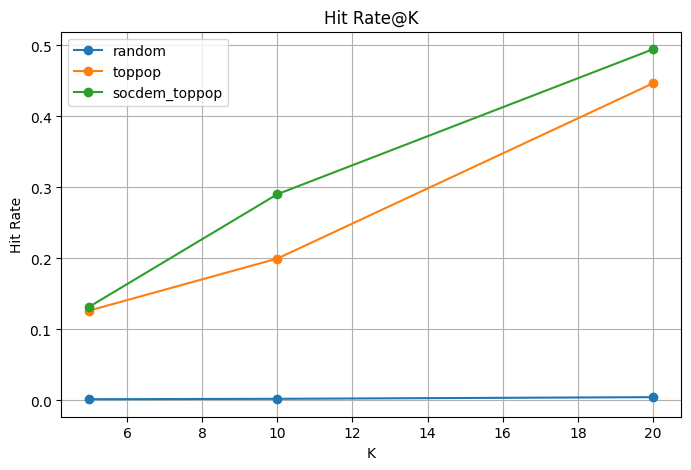

In [106]:
models = ["random", "toppop", "socdem_toppop"]

plt.figure(figsize=(8, 5))
for model in models:
    plt.plot(
        [5, 10, 20],
        [
            RESULTS.loc[model, "hit_rate@5"],
            RESULTS.loc[model, "hit_rate@10"],
            RESULTS.loc[model, "hit_rate@20"],
        ],
        marker="o",
        label=model,
    )

plt.xlabel("K")
plt.ylabel("Hit Rate")
plt.title("Hit Rate@K")
plt.legend()
plt.grid()
plt.show()

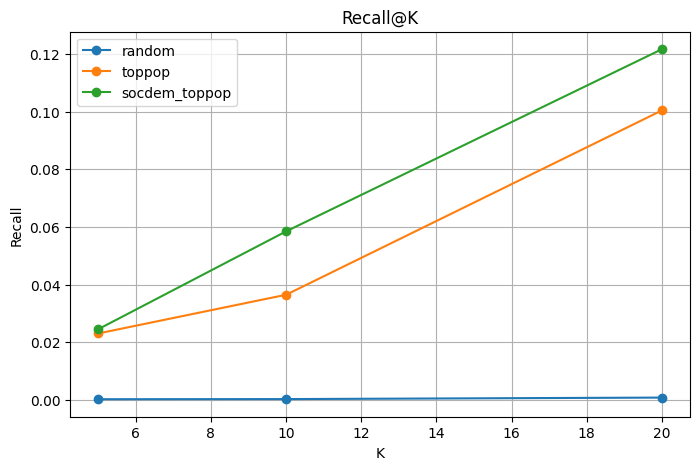

In [107]:
plt.figure(figsize=(8, 5))

for model in models:
    plt.plot(
        [5, 10, 20],
        [
            RESULTS.loc[model, "recall@5"],
            RESULTS.loc[model, "recall@10"],
            RESULTS.loc[model, "recall@20"],
        ],
        marker="o",
        label=model,
    )

plt.xlabel("K")
plt.ylabel("Recall")
plt.title("Recall@K")
plt.legend()
plt.grid()
plt.show()

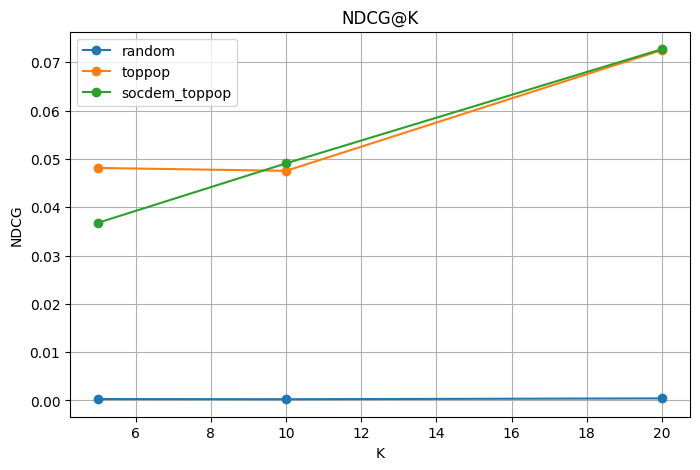

In [108]:
plt.figure(figsize=(8, 5))

for model in models:
    plt.plot(
        [5, 10, 20],
        [
            RESULTS.loc[model, "ndcg@5"],
            RESULTS.loc[model, "ndcg@10"],
            RESULTS.loc[model, "ndcg@20"],
        ],
        marker="o",
        label=model,
    )

plt.xlabel("K")
plt.ylabel("NDCG")
plt.title("NDCG@K")
plt.legend()
plt.grid()
plt.show()

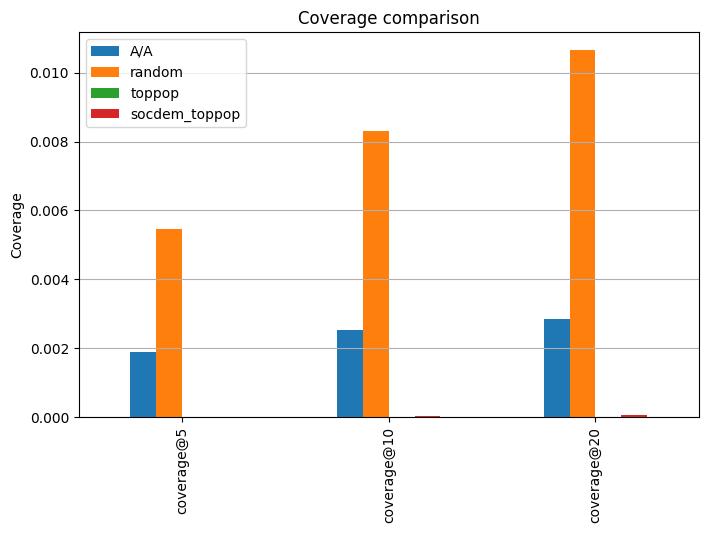

In [109]:
coverage = RESULTS[
    ["coverage@5", "coverage@10", "coverage@20"]
].T

coverage.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Coverage comparison")
plt.ylabel("Coverage")
plt.grid(axis="y")
plt.show()

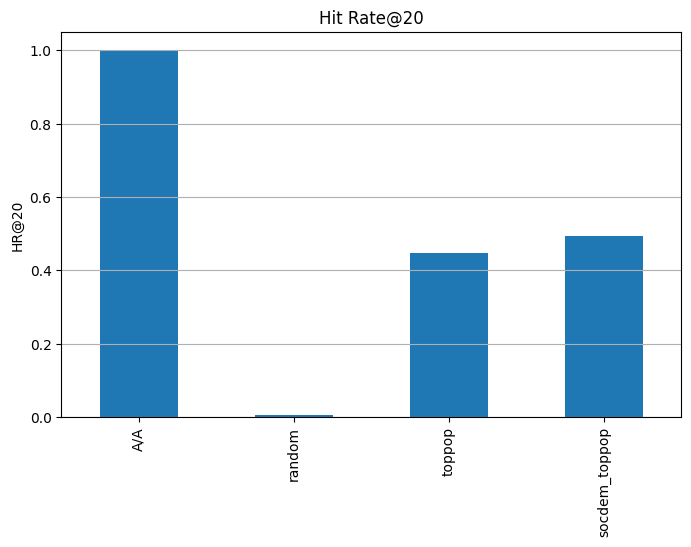

: 

In [ ]:
RESULTS["hit_rate@20"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Hit Rate@20")
plt.ylabel("HR@20")
plt.grid(axis="y")
plt.show()